===== DATA AWAL =====
                             CustomerID  Age  Gender  Annual_Income_USD  \
0  2f8c8c58-4779-4006-aa23-81db3a352da3   56  Female              79228   
1  4e6558a6-7f45-4f2a-8dfc-fb05210c5a54   69  Female              23205   
2  11ab8d14-6dd9-4a49-84cc-963431a8e6fc   46    Male              54929   
3  503e4ec0-42c7-4c2d-8cda-a480ad492b4b   32  Female             103384   
4  841426ba-7371-43b1-9cba-036d07d6c85e   60    Male              53411   

   Spending_Score Membership_Status Preferred_Payment_Method   Region  \
0              73            Bronze           Cryptocurrency  Central   
1              65            Silver           Cryptocurrency  Central   
2              68            Bronze               Debit Card  Central   
3              71            Bronze                   PayPal  Central   
4              11            Silver                   PayPal     West   

   Total_Purchases  Avg_Purchase_Value Last_Purchase_Date  Churn  \
0               17  

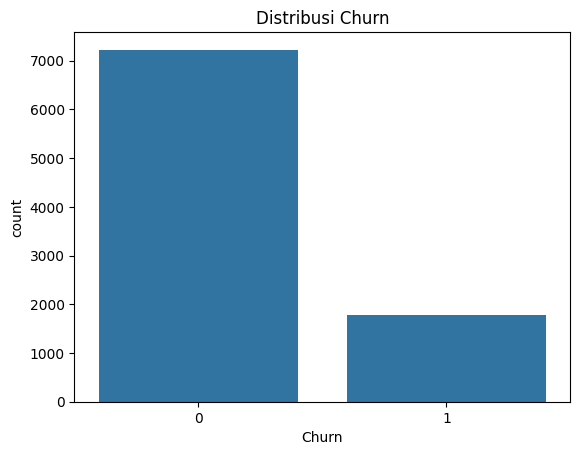

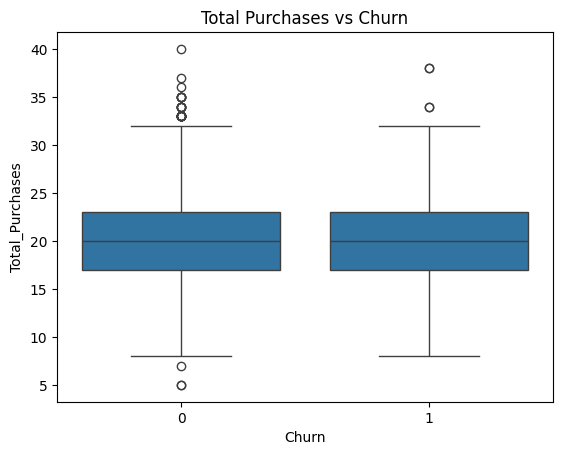

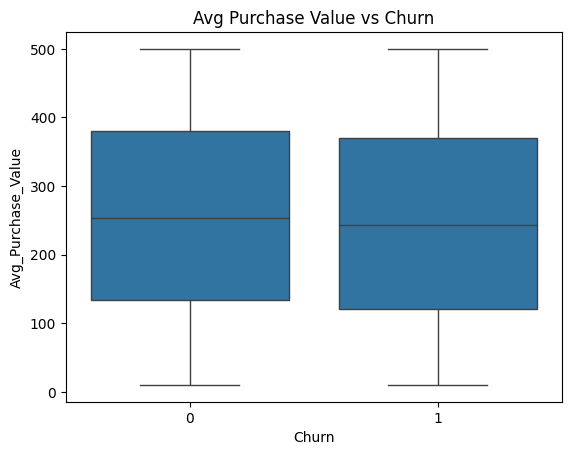

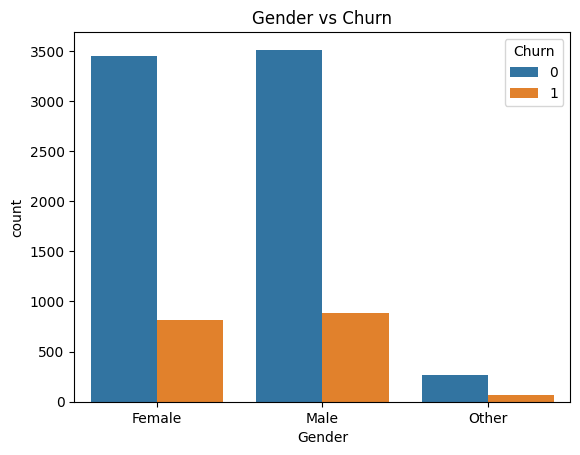

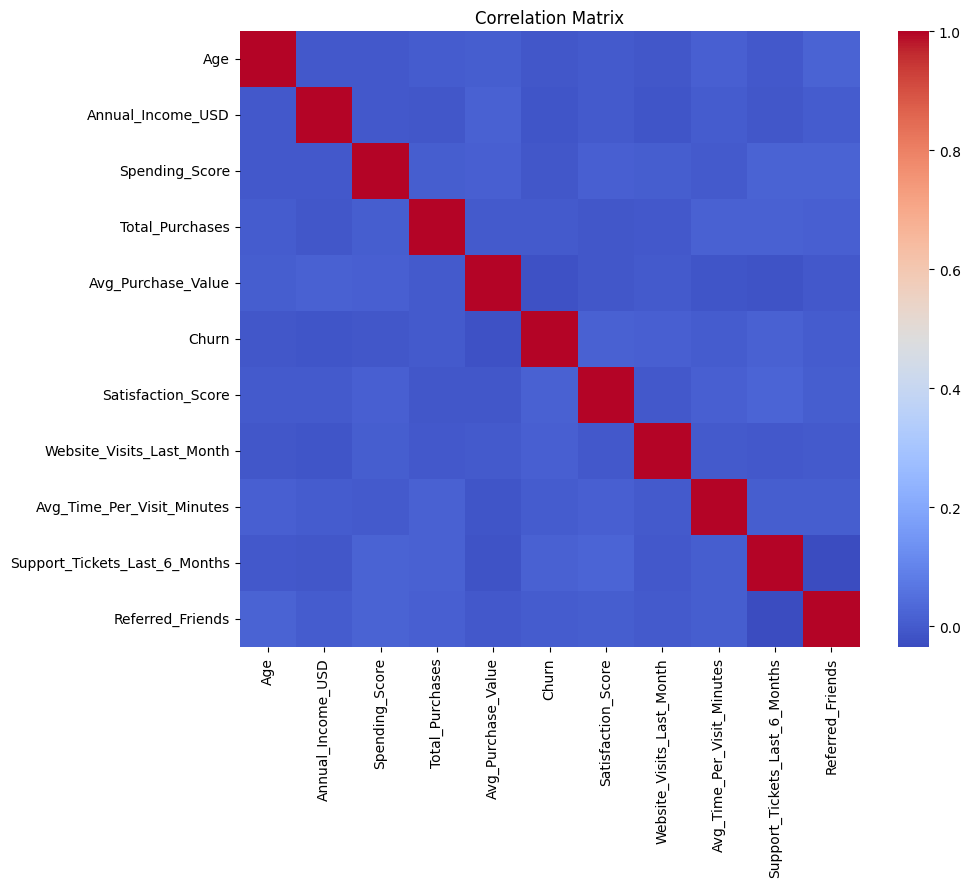


===== DATA SETELAH PREPROCESSING =====
   Age  Annual_Income_USD  Spending_Score  Total_Purchases  \
0   56              79228              73               17   
1   69              23205              65               21   
2   46              54929              68               25   
3   32             103384              71               25   
4   60              53411              11               24   

   Avg_Purchase_Value  Churn  Satisfaction_Score  Website_Visits_Last_Month  \
0              209.07      0                 2.3                          7   
1               25.60      0                 2.5                         14   
2              105.48      0                 4.6                         18   
3              381.95      1                 4.9                         20   
4              319.19      0                 1.2                         18   

   Avg_Time_Per_Visit_Minutes  Support_Tickets_Last_6_Months  ...  \
0                        3.01              

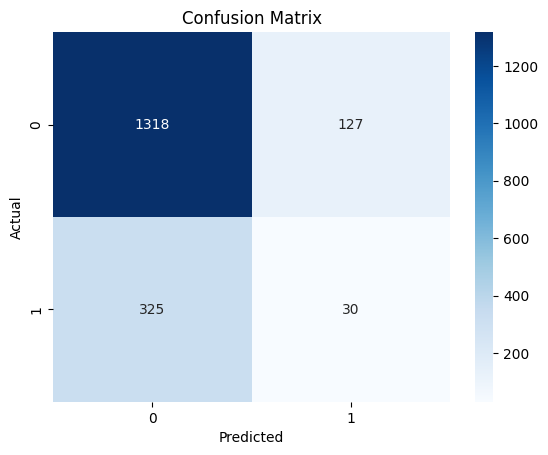

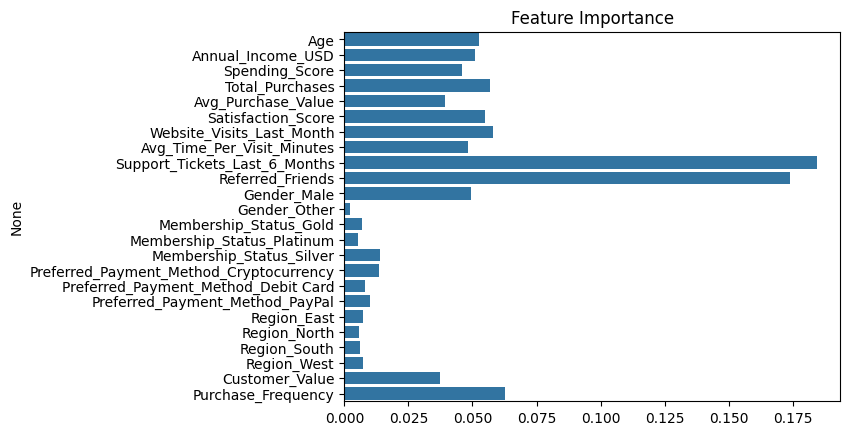


===== PREDIKSI 1 DATA =====
Hasil Prediksi (0 = Tidak Churn, 1 = Churn): 0


In [1]:
# ================================
# MACHINE LEARNING - CHURN PREDICTION
# ================================

# ===== 1. IMPORT LIBRARY =====
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE


# ===== 2. LOAD DATA =====
# Load dataset dari file CSV
df = pd.read_csv("data/dataset.csv")

print("===== DATA AWAL =====")
# Menampilkan 5 data pertama untuk melihat struktur data
print(df.head())


# ===== 3. INFORMASI DATASET =====
print("\n===== INFO DATASET =====")
# Menampilkan informasi kolom, tipe data, dan jumlah data
df.info()

print("\n===== DESKRIPSI DATA =====")
# Menampilkan statistik deskriptif data numerik
print(df.describe())


# ===== 4. CEK MISSING VALUE =====
print("\n===== MISSING VALUE =====")
# Mengecek apakah terdapat data kosong pada setiap kolom
print(df.isnull().sum())


# ===== 5. EDA (EXPLORATORY DATA ANALYSIS) =====
# Distribusi churn (target)
plt.figure()
sns.countplot(x='Churn', data=df)
plt.title("Distribusi Churn")
plt.show()

# Total transaksi vs churn
plt.figure()
sns.boxplot(x='Churn', y='Total_Purchases', data=df)
plt.title("Total Purchases vs Churn")
plt.show()

# Nilai rata-rata transaksi vs churn
plt.figure()
sns.boxplot(x='Churn', y='Avg_Purchase_Value', data=df)
plt.title("Avg Purchase Value vs Churn")
plt.show()

# Gender vs churn
plt.figure()
sns.countplot(x='Gender', hue='Churn', data=df)
plt.title("Gender vs Churn")
plt.show()

# Korelasi antar fitur numerik
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


# ===== 6. PREPROCESSING =====
# Menghapus kolom yang tidak relevan untuk modeling
df = df.drop(['CustomerID', 'Last_Purchase_Date'], axis=1)

# Mengisi missing value dengan rata-rata (hanya untuk kolom numerik)
df = df.fillna(df.mean(numeric_only=True))

# Mengubah data kategorikal menjadi numerik (encoding)
df = pd.get_dummies(df, drop_first=True)

print("\n===== DATA SETELAH PREPROCESSING =====")
# Menampilkan data setelah encoding dan cleaning
print(df.head())


# ===== 7. FEATURE EXTRACTION =====
# Membuat fitur baru: nilai total pelanggan
df['Customer_Value'] = df['Total_Purchases'] * df['Avg_Purchase_Value']

# Membuat fitur baru: frekuensi pembelian per bulan (estimasi)
df['Purchase_Frequency'] = df['Total_Purchases'] / 12

print("\n===== DATA SETELAH FEATURE EXTRACTION =====")
# Menampilkan data setelah penambahan fitur baru
print(df.head())


# ===== 8. SPLIT DATA =====
# Memisahkan fitur (X) dan target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Membagi data menjadi training dan testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ===== 9. SCALING =====
# Normalisasi data agar memiliki skala yang sama
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ===== 10. CEK IMBALANCE DATA =====
print("\n===== SEBELUM SMOTE =====")
# Mengecek distribusi kelas pada data training
print(y_train.value_counts())


# ===== 11. SMOTE =====
# Mengatasi ketidakseimbangan data menggunakan SMOTE
# Dilakukan hanya pada data training agar tidak terjadi data leakage
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\n===== SESUDAH SMOTE =====")
# Mengecek kembali distribusi data setelah balancing
print(pd.Series(y_train).value_counts())


# ===== 12. MODEL + GRID SEARCH =====
# Menggunakan Random Forest sebagai model klasifikasi
# random_state digunakan agar hasil konsisten setiap dijalankan
model = RandomForestClassifier(random_state=42)

# Parameter yang akan diuji untuk mendapatkan hasil terbaik
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

# Grid Search untuk mencari kombinasi parameter terbaik
grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

# Mengambil model terbaik hasil tuning
best_model = grid.best_estimator_

print("\n===== BEST PARAMETER =====")
print(grid.best_params_)


# ===== 13. EVALUASI MODEL =====
# Menggunakan model untuk prediksi data testing
y_pred = best_model.predict(X_test)

print("\n===== HASIL EVALUASI =====")
# Mengukur akurasi model
print("Accuracy:", accuracy_score(y_test, y_pred))

# Menampilkan precision, recall, f1-score
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# ===== 14. CONFUSION MATRIX =====
# Membuat confusion matrix untuk melihat performa klasifikasi
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ===== 15. FEATURE IMPORTANCE =====
# Mengambil tingkat kepentingan setiap fitur dari model
# Semakin tinggi nilainya, semakin besar pengaruh fitur terhadap prediksi churn
importances = best_model.feature_importances_

# Mengambil nama fitur
features = X.columns

# Visualisasi fitur paling berpengaruh
plt.figure()
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()


# ===== 16. PREDIKSI 1 DATA =====
# Mengambil satu data dari testing untuk diprediksi
sample = X_test[0].reshape(1, -1)

# Melakukan prediksi
prediction = best_model.predict(sample)

print("\n===== PREDIKSI 1 DATA =====")
print("Hasil Prediksi (0 = Tidak Churn, 1 = Churn):", prediction[0])